# Ultra-Marathon Performance Visualization — Part B
### Speed Distributions & Performance Over Time

**Group 17** — Luiz Samelo, Maximilian Staudacher, Rayudu Muralikrishna

This notebook covers two visualizations focused on speed distributions and 
long-term performance trends in ultra-marathon running, using the 
[Big Dataset of Ultra-Marathon Running](https://www.kaggle.com/datasets/aiaiaidavid/the-big-dataset-of-ultra-marathon-running)
(~7M records, 1798–2022).

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")


In [34]:
cols_needed = ["Year of event", "Event distance/length", "Athlete average speed"]
distances_wanted = ["50km", "50mi", "100km"]
chunks = []

for chunk in pd.read_csv(
    "../data/TWO_CENTURIES_OF_UM_RACES.csv",
    usecols=cols_needed,
    chunksize=200_000,
    low_memory=False
):
    chunk = chunk[chunk["Event distance/length"].isin(distances_wanted)]
    chunk = chunk.dropna(subset=["Athlete average speed"])
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(df.shape)
print(df["Event distance/length"].value_counts())
print(df["Athlete average speed"].describe())

(2826531, 3)
Event distance/length
50km     1522608
100km     951742
50mi      352181
Name: count, dtype: int64
count     2826531
unique      47752
top         7.282
freq          903
Name: Athlete average speed, dtype: object


In [35]:
df["Athlete average speed"] = pd.to_numeric(df["Athlete average speed"], errors="coerce")
df = df.dropna(subset=["Athlete average speed"])

print(df.shape)
print(df["Athlete average speed"].describe())

(2826411, 3)
count    2.826411e+06
mean     7.514402e+02
std      2.476926e+03
min      1.920000e-01
25%      6.324000e+00
50%      7.720000e+00
75%      9.468000e+00
max      2.830200e+04
Name: Athlete average speed, dtype: float64


In [36]:
# Record de 50km é ~18 km/h; qualquer coisa acima de 20 é outlier
df = df[(df["Athlete average speed"] >= 2) & (df["Athlete average speed"] <= 20)]

print(df.shape)
print(df["Athlete average speed"].describe())

(2573579, 3)
count    2.573579e+06
mean     7.599998e+00
std      2.140008e+00
min      2.012000e+00
25%      6.171000e+00
50%      7.472000e+00
75%      8.858000e+00
max      1.989600e+01
Name: Athlete average speed, dtype: float64


### Visualization 3: Speed Distribution Across Ultra-Marathon Distances

This box plot displays the distribution of average finishing speeds (km/h) across
three ultra-marathon distances: 50 km, 50 miles (~80 km), and 100 km. Data is
filtered to post-1980 races to ensure sufficient sample sizes across all three
distances, resulting in over 2.5 million records.

The distances are ordered by actual length to make performance degradation
immediately apparent. Individual outlier markers are hidden (`showfliers=False`)
due to dataset size; extreme values outside the physiologically plausible range
of 2–20 km/h were removed prior to plotting.

The chart reveals that as race distance increases, both median speed and
inter-quartile range change: 50 km shows the highest median (~7.8 km/h) and the
tightest spread, reflecting a more competitive, homogeneous field. The 100 km
distance shows wider variability, consistent with a broader participation base
ranging from elite athletes to recreational finishers.

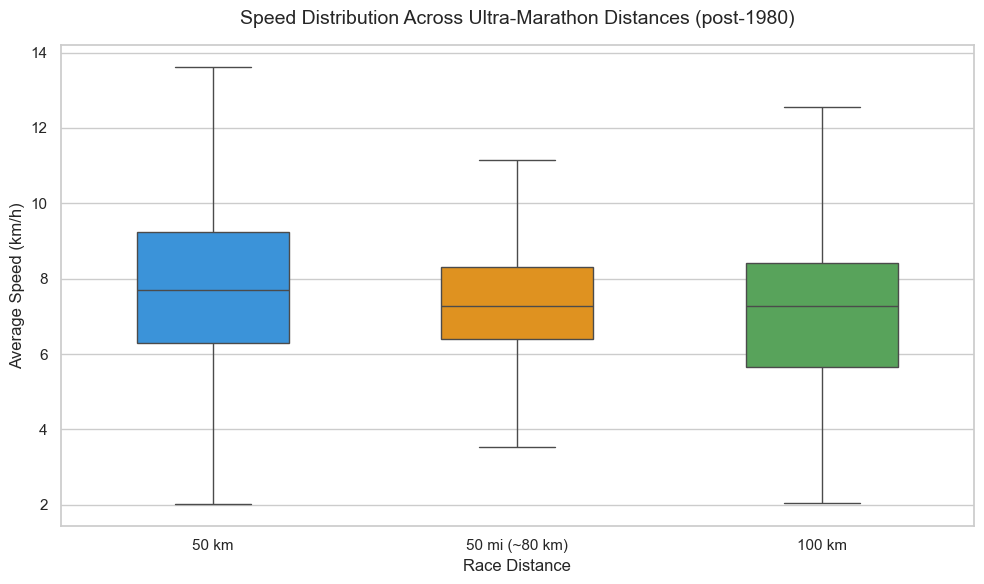

In [37]:
# --- Viz 3: Speed distribution by distance ---
# Filter post-1980 as stated in the proposal
df_viz3 = df[df["Year of event"] >= 1980].copy()

distance_order = ["50km", "50mi", "100km"]  # ordered by actual distance

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_viz3,
    x="Event distance/length",
    y="Athlete average speed",
    order=distance_order,
    hue="Event distance/length",
    palette=["#2196F3", "#FF9800", "#4CAF50"],
    width=0.5,
    showfliers=False,
    legend=False,
    ax=ax
)

ax.set_title("Speed Distribution Across Ultra-Marathon Distances (post-1980)", fontsize=14, pad=15)
ax.set_xlabel("Race Distance", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["50 km", "50 mi (~80 km)", "100 km"])

plt.tight_layout()
plt.savefig("../Viz/viz3_boxplots_speed_by_distance.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 4: Elite vs. Median Performance in 50km Races Over Time

This line chart tracks two performance metrics in 50 km races from the mid-1990s
to 2022: the mean speed of the top 10 finishers per year (elite) and the median
speed of all finishers (field median). A shaded area between the lines highlights
the evolving gap between elite and average performance.

Only years with at least 50 recorded finishers are included to avoid small-sample
noise — this is why the series begins around 1996 rather than 1972. "Elite" is
defined per year as the mean speed of the 10 fastest individual results, chosen
as a robust proxy for top-end competitive performance.

The visualization reveals a clear divergence: elite performance remains stable
at ~17–18 km/h throughout the period, while the field median declines steadily
from ~9.3 km/h in the late 1990s to ~7.2 km/h in 2022. This widening gap
directly supports our hypothesis — as ultra-marathon running grew globally and
attracted recreational participants, the median finisher became slower while the
elite field maintained and slightly improved its level.

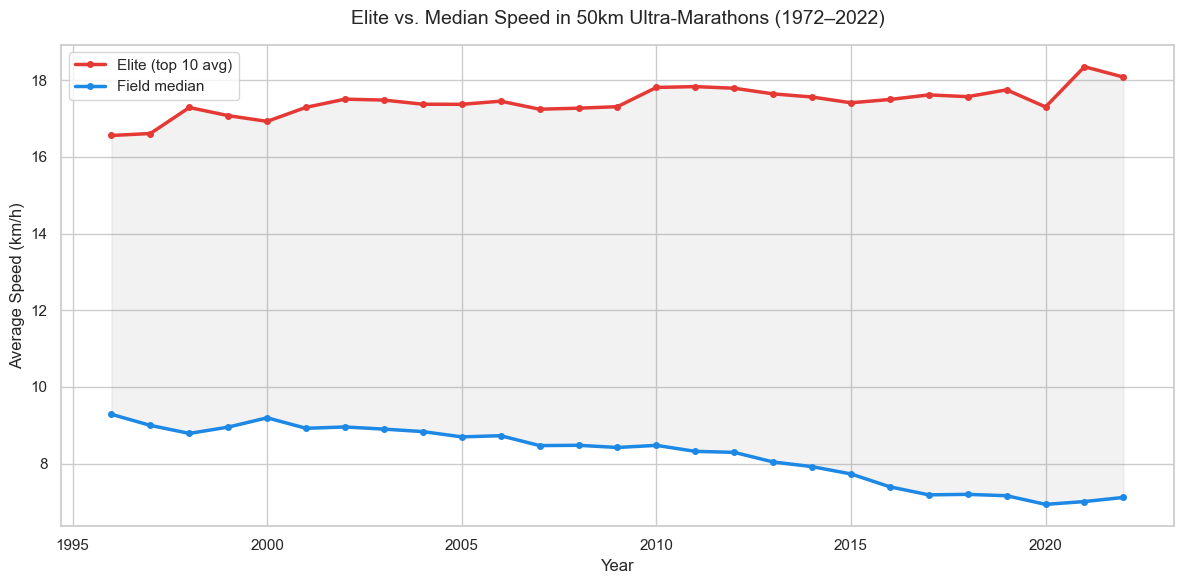

In [38]:
# --- Viz 4: Elite (top 10) vs Median speed in 50km races over time ---

df_50k = df[
    (df["Event distance/length"] == "50km") &
    (df["Year of event"] >= 1972)
].copy()

# per year: média dos 10 mais rápidos vs mediana geral (min 50 finishers)
yearly = df_50k.groupby("Year of event")["Athlete average speed"].agg(
    elite=lambda x: x.nlargest(10).mean() if len(x) >= 50 else np.nan,
    median=lambda x: x.median() if len(x) >= 50 else np.nan,
    count="count"
).reset_index()

yearly = yearly[yearly["count"] >= 50].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly["Year of event"], yearly["elite"],
        color="#E53935", linewidth=2.5, marker="o", markersize=4, label="Elite (top 10 avg)")
ax.plot(yearly["Year of event"], yearly["median"],
        color="#1E88E5", linewidth=2.5, marker="o", markersize=4, label="Field median")

ax.fill_between(yearly["Year of event"], yearly["elite"], yearly["median"],
                alpha=0.1, color="gray")

ax.set_title("Elite vs. Median Speed in 50km Ultra-Marathons (1972–2022)", fontsize=14, pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../Viz/viz4_elite_vs_median.png", dpi=150, bbox_inches="tight")
plt.show()